Found 1668 images belonging to 17 classes.
Found 408 images belonging to 17 classes.
Number of Classes: 17
Class Index: {'Avulsion fracture': 0, 'Closed(simple) fracture': 1, 'Comminuted fracture': 2, 'Compression-Crush fracture': 3, 'Fracture Dislocation': 4, 'Greenstick fracture': 5, 'Hairline Fracture': 6, 'Impacted fracture': 7, 'Intra-articular fracture': 8, 'Longitudinal fracture': 9, 'Oblique fracture': 10, 'Open(compound) fracture': 11, 'Pathological fracture': 12, 'Segmental fracture': 13, 'Spiral Fracture': 14, 'Stress fracture': 15, 'Transverse fracture': 16}
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 10, 10, 2048)      23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
       

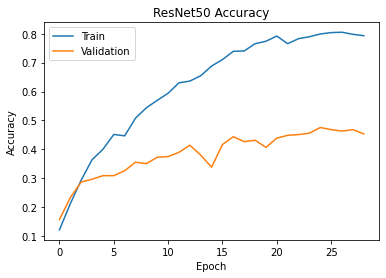

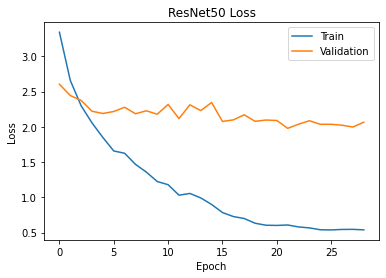

C:\Users\Nick\AppData\Roaming\Python\Python39\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


ResNet50 Model Saved Successfully
Best Validation Accuracy: 0.47549018263816833
Best Validation Loss: 1.979207992553711


In [1]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 300
BATCH_SIZE = 32
EPOCHS = 50

dataset_path = "dataset"

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

num_classes = train_gen.num_classes

print("Number of Classes:", num_classes)
print("Class Index:", train_gen.class_indices)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers[:-50]:
    layer.trainable = False

model = models.Sequential([
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.BatchNormalization(),
    
    layers.Dense(1024, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.4),
    
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights
)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("ResNet50 Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("ResNet50 Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

model.save("bone_fracture_resnet50_model.h5")

print("ResNet50 Model Saved Successfully")

best_acc = max(history.history["val_accuracy"])
best_loss = min(history.history["val_loss"])

print("Best Validation Accuracy:", best_acc)
print("Best Validation Loss:", best_loss)

In [8]:
final_train_acc = history.history["accuracy"][-1]*100
final_val_acc = history.history["val_accuracy"][-1]*100

print("Final Training Accuracy:", final_train_acc)
print("Final Validation Accuracy", final_val_acc)

Final Training Accuracy: 79.31654453277588
Final Validation Accuracy 45.34313678741455


In [9]:
best_train_acc = max(history.history["accuracy"])*100
best_val_acc = max(history.history["val_accuracy"])*100

print("Best Training Accuracy:", best_train_acc)
print("Best Validation Accuracy:", best_val_acc)

Best Training Accuracy: 80.5155873298645
Best Validation Accuracy: 47.54901826381683


In [3]:

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 300

model = tf.keras.models.load_model("bone_fracture_resnet50_model.h5")

class_names = [
    'Avulsion fracture',
    'Closed(simple) fracture',
    'Comminuted fracture',
    'Compression-Crush fracture',
    'Fracture Dislocation',
    'Greenstick fracture',
    'Hairline Fracture',
    'Impacted fracture',
    'Intra-articular fracture',
    'Longitudinal fracture',
    'Oblique fracture',
    'Open(compound) fracture',
    'Pathological fracture',
    'Segmental fracture',
    'Spiral Fracture',
    'Stress fracture',
    'Transverse fracture'
]

def fracture_severity(conf):
    if conf < 0.4:
        return "Very Mild", conf * 100
    elif conf < 0.6:
        return "Mild", conf * 100
    elif conf < 0.8:
        return "Moderate", conf * 100
    else:
        return "Severe", conf * 100

def predict(img_path):

    
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)

    
    img_array = np.expand_dims(img_array, axis=0)

    
    img_array = preprocess_input(img_array)

    
    pred = model.predict(img_array)

    idx = np.argmax(pred)
    conf = float(np.max(pred))
    label = class_names[idx]

    print("\nPrediction:", label)
    print("Confidence:", round(conf * 100, 2), "%")

    
    print("\nAll Class Probabilities:")
    for i, p in enumerate(pred[0]):
        print(f"{class_names[i]}: {round(p*100,2)}%")

    
    sev, perc = fracture_severity(conf)
    print("\nSeverity:", sev)
    print("Severity %:", round(perc, 2))


predict("C:\Anshul\M.tech\PBL\PBL_Project\dataset\Avulsion fracture\1-s2.0-S0899707114002836-gr2.jpg")  

TypeError: weight_decay is not a valid argument, kwargs should be empty  for `optimizer_experimental.Optimizer`.